<a href="https://colab.research.google.com/github/abakwofie/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Dataset Shape
(41202, 13)

First 5 rows


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



Data Types and Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Summary


,count,mean,std,min,25%,50%,75%,max
VendorID,41202.0,2.000000,0.000000,2.00,2.00,2.00,2.00,2.00
passenger_count,41202.0,1.633926,0.924250,1.00,1.00,1.00,2.00,8.00
trip_distance,41202.0,18.384928,2.856605,0.00,17.37,18.18,19.38,189.91
RatecodeID,41202.0,2.025411,0.461587,1.00,2.00,2.00,2.00,5.00
store_and_fwd_flag,41202.0,0.999393,0.024625,0.00,1.00,1.00,1.00,1.00
PULocationID,41202.0,132.220475,7.726159,10.00,132.00,132.00,132.00,264.00
DOLocationID,41202.0,164.546333,67.901529,3.00,113.00,163.00,231.00,265.00
payment_type,41202.0,1.000000,0.000000,1.00,1.00,1.00,1.00,1.00
fare_amount,41202.0,69.986150,6.184851,3.70,70.00,70.00,70.00,199.70
mta_tax,41202.0,0.491020,0.066404,0.00,0.50,0.50,0.50,0.50



Missing Values per Column
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

Distribution of 'tip_amount' 


<function matplotlib.pyplot.show(close=None, block=None)>

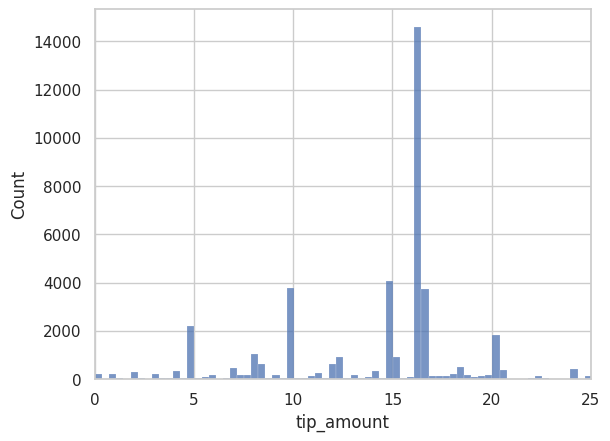

In [5]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print('Dataset Shape')
print(taxi.shape)
print()

print('First 5 rows')
display(taxi.head())
print()

print('Data Types and Info')
taxi.info()
print()

print('Summary')
display(taxi.describe().T)
print()

# - count missing values per column:
print('Missing Values per Column')
print(taxi.isna().sum())
print()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
print("Distribution of 'tip_amount' ")
sns.histplot(data = taxi, x = 'tip_amount')
plt.xlim(0,25)
plt.show



Answer: The dataset contains 41,202 rows and 13 columns. Although the dataset doesn't contain any missing values, there are some impossible values such as trip_distance having a minimum value of 0.00 even though the minimum fare_amount is 3.70. The tip_amount distribution is left-skewed. It ranges from a minimum value of 0.01 to a maximum value of 98.00, with a mean of 14.1. This influences preprocessing because the rows where trip_distance == 0 must be removed to prevent impossible trips from skewing the model's predictions.

In [13]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi_clean = taxi[taxi['trip_distance'] > 0].copy()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
for col in categorical_cols:
    taxi_clean[col] = taxi_clean[col].astype(str)

taxi_final = pd.get_dummies(taxi_clean, columns=categorical_cols)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax',
                'tolls_amount', 'improvement_surcharge', 'fare_per_mile', 'total_surcharges']

1. I removed rows where trip_distance == 0 because a taxi trip cannot be completed and a passenger cannot be charged if the taxi never went anywhere

2. I created fare_per_mile to show how things like traffic and the overall distance of a trip influence the fare. I created total_surcharges to sum up the involuntary and sometimes unknown costs added to the passenger's fare

3. StandardScaler was chosen because numeric features like distance and fares have different ranges and units. It standardizes the data such that the data set has a mean of 0 and a standard deviation of 1.

In [14]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X = taxi_final.drop(columns=['tip_amount'])
y = taxi_final['tip_amount']

X_remain, X_test, y_remain, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_remain, y_remain, test_size=0.25, random_state=RANDOM_STATE
)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

We must fit the scaler strictly on the training set to avoid data leakage. The scaler calculates the mean and standard deviation of the data. If we fit it using the validation or test sets, the model gets information about the averages and ranges of our unseen data before making predictions. Using .fit_transform() only on the training set and .transform() on the validation and test sets keeps our evaluation completely pure.


I used a 60/20/20 split for the training validation and test sets. A separate validation is useful to prep the model for the test set. If the test set was used instead, the model would just memorize it. So keeping them separate ensures that the set is completely unbiased and unaware of the data points in the test set. The scalar must be fit on only the training data to ensure that the model remains unaware about the details of the validation and test data

LINEAR REGRESSION METRICS
Train - RMSE: 4.8045 , R^2: 0.0513
Val - RMSE: 5.0371 , R^2: 0.0486
Test - RMSE: 5.0132 , R^2: 0.0511

DECISION TREE METRICS
Train - RMSE: 4.6539 , R^2: 0.1099
Val - RMSE: 5.2128 , R^2: -0.0189
Test - RMSE: 5.237 , R^2: -0.0356


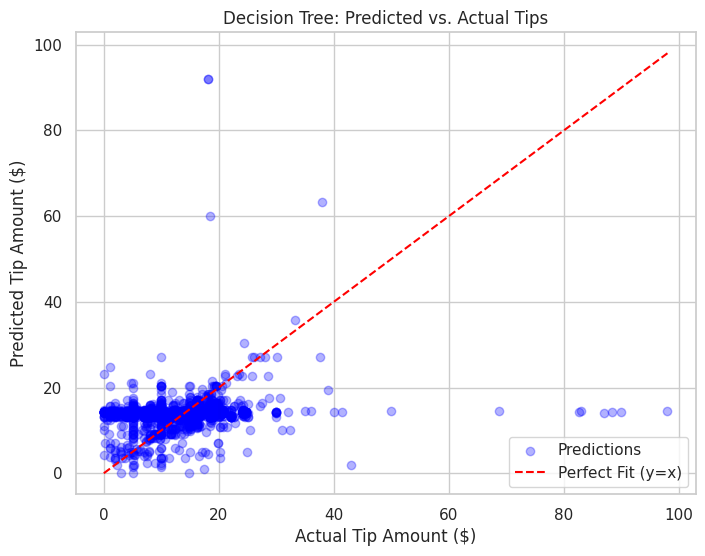

In [16]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

# TODO: Predict on train, validation, and test sets.
# (We will get predictions for both to compare their metrics below)
lr_train_pred = lr_model.predict(X_train)
lr_val_pred = lr_model.predict(X_val)
lr_test_pred = lr_model.predict(X_test)

dt_train_pred = dt_model.predict(X_train)
dt_val_pred = dt_model.predict(X_val)
dt_test_pred = dt_model.predict(X_test)

# TODO: Report RMSE and R^2 for ALL THREE sets.
from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
lr_train_rmse = mean_squared_error(y_train, lr_train_pred) ** 0.5
lr_train_r2 = r2_score(y_train, lr_train_pred)

lr_val_rmse = mean_squared_error(y_val, lr_val_pred) ** 0.5
lr_val_r2 = r2_score(y_val, lr_val_pred)

lr_test_rmse = mean_squared_error(y_test, lr_test_pred) ** 0.5
lr_test_r2 = r2_score(y_test, lr_test_pred)

dt_train_rmse = mean_squared_error(y_train, dt_train_pred) ** 0.5
dt_train_r2 = r2_score(y_train, dt_train_pred)

dt_val_rmse = mean_squared_error(y_val, dt_val_pred) ** 0.5
dt_val_r2 = r2_score(y_val, dt_val_pred)

dt_test_rmse = mean_squared_error(y_test, dt_test_pred) ** 0.5
dt_test_r2 = r2_score(y_test, dt_test_pred)

print("LINEAR REGRESSION METRICS")
print("Train - RMSE:", round(lr_train_rmse, 4), ", R^2:", round(lr_train_r2, 4))
print("Val - RMSE:", round(lr_val_rmse, 4), ", R^2:", round(lr_val_r2, 4))
print("Test - RMSE:", round(lr_test_rmse, 4), ", R^2:", round(lr_test_r2, 4))
print()
print("DECISION TREE METRICS")
print("Train - RMSE:", round(dt_train_rmse, 4), ", R^2:", round(dt_train_r2, 4))
print("Val - RMSE:", round(dt_val_rmse, 4), ", R^2:", round(dt_val_r2, 4))
print("Test - RMSE:", round(dt_test_rmse, 4), ", R^2:", round(dt_test_r2, 4))

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_test_pred, alpha=0.3, color='blue', label='Predictions')

# Reference line (y=x)
max_val = max(max(y_test), max(dt_test_pred))
min_val = min(min(y_test), min(dt_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')

plt.xlabel('Actual Tip Amount ($)')
plt.ylabel('Predicted Tip Amount ($)')
plt.title('Decision Tree: Predicted vs. Actual Tips')
plt.legend()
plt.grid(True)
plt.show()

 1. The Decision Tree Regressor performed best on the training set, but Linear Regression did better on the validation set because it didn't have negative R^2 values. I used a max_depth=10 hyperparameter for the tree to prevent the tree from continuously splitting

 2. The Decision Tree is overfitting. Its training R^2 is its highest score (0.1099), but it decreases into negative numbers on the validation (-0.0189) and test sets (-0.0356) because it just memorized noise.

 3. To reduce this overfitting, I would lower the max_depth to 4to simplify the tree structure.

Dataset Shape
(2111, 17)

First 5 Rows


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                 

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing Values
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Target Class Distribution
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


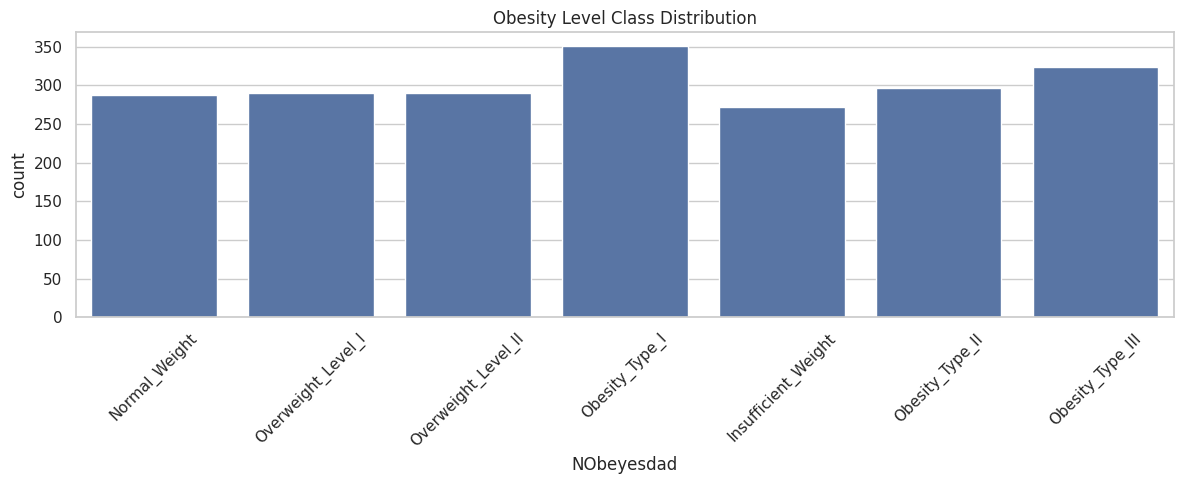

In [19]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Dataset Shape")
print(obesity.shape)
print()

print("First 5 Rows")
display(obesity.head())
print()

print("Dataset Info")
obesity.info()
print()

print("\n--- Summary Statistics ---")
display(obesity.describe())
print()

print("Missing Values")
print(obesity.isnull().sum())
print()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("Target Class Distribution")
class_counts = obesity['NObeyesdad'].value_counts()
print(class_counts)

plt.figure(figsize=(12, 5))
sns.countplot(data=obesity, x='NObeyesdad')
plt.xticks(rotation=45)
plt.title("Obesity Level Class Distribution")
plt.tight_layout()
plt.show()


There are 2,111 rows and 17 columns in this dataset.

The categorical columns are Gender, family_history_with_overweight, FAVC, SMOKE, SCC, CAEC, CALC, MTRANS, and the target NObeyesdad. The numeric columns are Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE.

The target is relatively balanced because all 7 categories have a very similar number of rows (each sitting between roughly 250 and 350 counts). Class balance matters because if one class heavily dominated the data, a lazy model could just blindly guess that dominant class every time to get high accuracy while completely failing to learn any of the other categories.

In [21]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesity_copy = obesity.copy()
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_copy[col] = obesity_copy[col].map({'yes': 1, 'no': 0})

obesity_copy['Gender'] = obesity_copy['Gender'].map({'Female': 1, 'Male': 0})

categorical_cols = ['CAEC', 'CALC', 'MTRANS']
obesity_copy = pd.get_dummies(obesity_copy, columns=categorical_cols, drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity_copy['BMI'] = obesity_copy['Weight'] / (obesity_copy['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder
target_encoder = LabelEncoder()
obesity_copy['NObeyesdad_encoded'] = target_encoder.fit_transform(obesity_copy['NObeyesdad'])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
scaler = StandardScaler()

1. I mapped binary columns (yes/no and Gender) directly to 0 and 1 since they only have two unique states. For the multi-option categorical features (CAEC, CALC, MTRANS), I used one-hot encoding to prevent the model from assuming a false mathematical ranking or order among nominal choices like transportation methods

2. I engineered a BMI feature by dividing weight by height squared. Including BMI technically may makes the classification task too easy because clinical obesity categories are clearly and explicitly defined by strict BMI thresholds. This acts as a form of target leakage, giving the model a massive shortcut to the answer.

3. I initialized a StandardScaler to normalize the numeric features. Because features like Age and Weight have completely different scales and variances, centering them around a mean of 0 with a standard deviation of 1 ensures that no single feature dominates the model's distance calculations or weight updates.

In [22]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity_copy.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = obesity_copy['NObeyesdad_encoded']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)

# Step 2: Split Temp evenly into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

I chose a 60/20/20 split for the training, validation, and test sets.

Setting stratify=y ensures that each of the three splits maintains the exact same proportions of the 7 obesity classes as the original dataset.

Random splitting could accidentally clump certain classes together. For instance, an entire class like Insufficient_Weight might end up completely in the test set by pure chance. The model would never see it during training, making it impossible to learn how to classify it, which ruins evaluation metrics.

CLASSIFICATION PERFORMANCE
Train -> Accuracy: 1.0 , Macro-F1: 1.0
Val   -> Accuracy: 0.9834 , Macro-F1: 0.9831
Test  -> Accuracy: 0.9598 , Macro-F1: 0.9591

--- Confusion Matrix ---


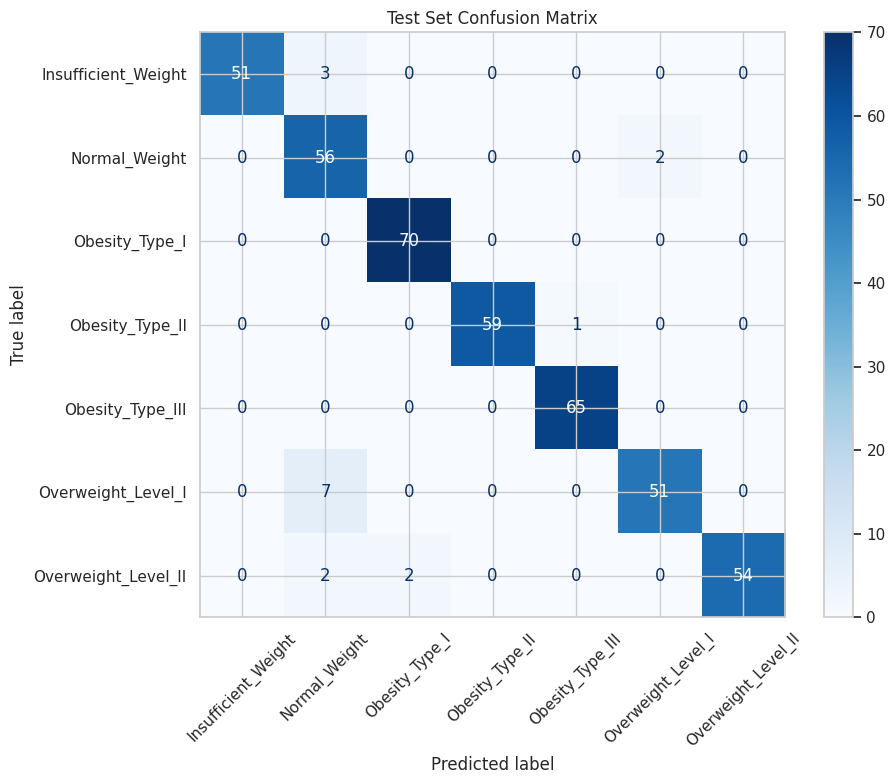

In [24]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
clf_model = RandomForestClassifier(random_state=RANDOM_STATE)
clf_model.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test.
clf_train_pred = clf_model.predict(X_train_scaled)
clf_val_pred = clf_model.predict(X_val_scaled)
clf_test_pred = clf_model.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
from sklearn.metrics import accuracy_score, f1_score, classification_report
train_acc = accuracy_score(y_train, clf_train_pred)
train_f1 = f1_score(y_train, clf_train_pred, average='macro')

val_acc = accuracy_score(y_val, clf_val_pred)
val_f1 = f1_score(y_val, clf_val_pred, average='macro')

test_acc = accuracy_score(y_test, clf_test_pred)
test_f1 = f1_score(y_test, clf_test_pred, average='macro')

print("CLASSIFICATION PERFORMANCE")
print("Train -> Accuracy:", round(train_acc, 4), ", Macro-F1:", round(train_f1, 4))
print("Val   -> Accuracy:", round(val_acc, 4), ", Macro-F1:", round(val_f1, 4))
print("Test  -> Accuracy:", round(test_acc, 4), ", Macro-F1:", round(test_f1, 4))

# TODO: Show a confusion matrix for the test set
from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
print("\n--- Confusion Matrix ---")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    clf_model, X_test_scaled, y_test,
    display_labels=target_encoder.classes_,
    ax=ax, cmap='Blues', xticks_rotation=45
)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

1. I chose a Random Forest Classifier because the dataset consists of a mix of binary, categorical, and numerical columns. Decision tree-based ensemble methods are highly efficient at handling multiple data types in one data set and capturing non-linear feature relationships without a hyperparameter.

2. The model is well-fitted. While it achieves a perfect 1.0 score on training, the validation accuracy (98.34%) and test accuracy (95.98%) are still very high/strong. The performance is high because including the engineered BMI feature acts as a massive hint for predicting obesity classes.

3. The most prominent mistakes occur between Overweight_Level_I and Normal_Weight (7 actual Overweight_Level_I individuals were misclassified as Normal_Weight). This happens because these categories represent adjacent ranges along a continuous  weight spectrum, which makes very closely related individuals nearly identical in features.

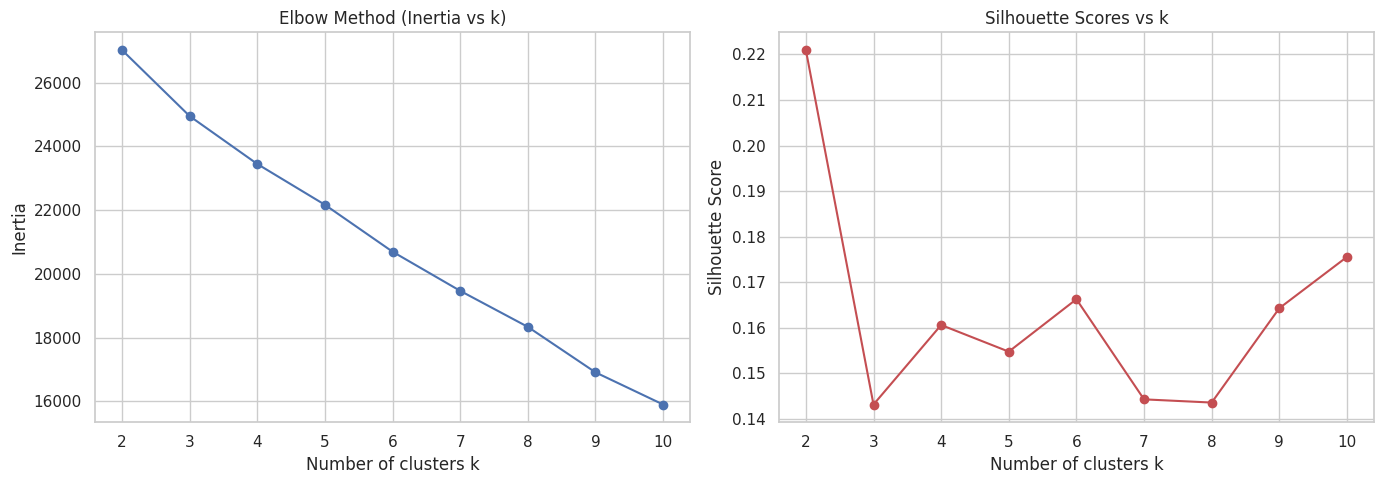

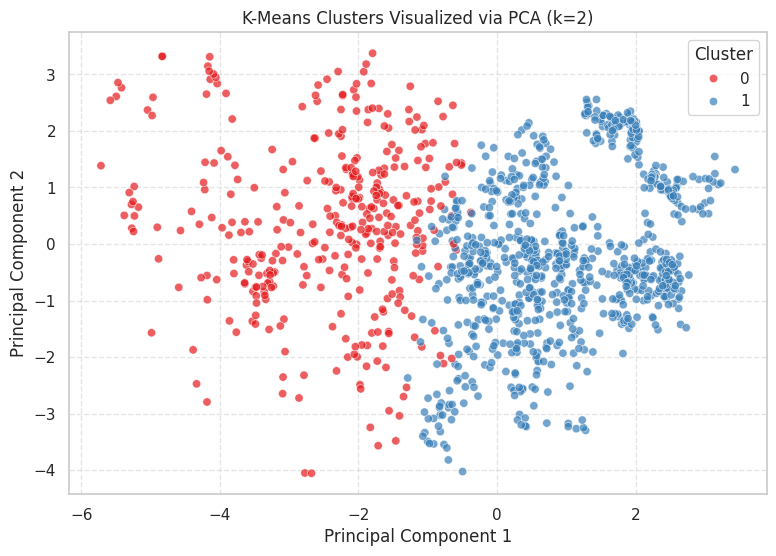

In [27]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_clustering = X_train_scaled

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_test.fit(X_train_scaled)

    inertias.append(kmeans_test.inertia_)

    score = silhouette_score(X_train_scaled, kmeans_test.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, marker='o', color='b')
ax1.set_title("Elbow Method (Inertia vs k)")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, marker='o', color='r')
ax2.set_title("Silhouette Scores vs k")
ax2.set_xlabel("Number of clusters k")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 2
kmeans_model = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
kmeans_model.fit(X_clustering)
cluster_labels = kmeans_model.labels_

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clustering)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set1', alpha=0.7)
plt.title("K-Means Clusters Visualized via PCA (k=2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [29]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
y_train_text = target_encoder.inverse_transform(y_train)

obesity_crosstab = pd.crosstab(cluster_labels, y_train_text)

print("Cluster vs True Obesity Level Crosstab")
print(obesity_crosstab)

Cluster vs True Obesity Level Crosstab
col_0  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  \
row_0                                                                        
0                      121            149               5                1   
1                       42             23             206              177   

col_0  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  
row_0                                                             
0                     0                  57                   40  
1                   194                 117                  134  


1. I evaluated the dataset using both the Elbow method and Silhouette scores. The Silhouette score plot revealed a peak at k = 2, while the Elbow curve began to delfect right after k = 2

2. Looking at the crosstab, the unsupervised clusters split the dataset into a "Lower-Risk/Weight" group (Cluster 0) and a "Higher-Risk/Obesity" group (Cluster 1).

**Where they agree:** The extreme values were grouped clearly. Obesity_Type_III is captured 100% perfectly in Cluster 1 (194 to 0), and Obesity_Type_I and II heavily lean into Cluster 1. Conversely, the vast majority of Insufficient_Weight and Normal_Weight individuals group into Cluster 0.

**Where they break down:** The clusters are less distinct in the mid-range Overweight tiers. Overweight_Level_I and Overweight_Level_II split between both clusters (e.g., 57 vs 117) rather than each having a distinct cluster, showing that unsupervised learning cannot cleanly draw boundries between median categories.

3. These clusters would be useful for categorising patients into high (Cluster 1) and low (Cluster 0) risk subgroups.

1. The classifier learnt how to draw clear boundaries that align with medical definition whereas K-Mean could only group data points by mathematical similarity (like being within a set range) while caused it to group the median categories together. However, K-Means is able to split the data into two clear categories (high risk and low risk)

2. Evaluating a continuous target (tips) means predicting an infinite range of numeric values, where we measure success by how close the prediction is to the actual number using metrics like Mean Squared Error. Evaluating a categorical target (obesity level) means sorting data points into clear, distinct groups, where success is measured by discrete correctness using a confusion matrix, accuracy, and precision.

3. The biggest train-vs-test performance gap occurs when models are allowed to grow too complex (like unrestricted Decision Trees), causing them to memorize the training data instead of finding general trends. The single most effective way to close this gap is regularization, which includes techniques like limiting a tree's maximum depth (max_depth).